# Sex & Individual ID Training Workflow

Dieses Notebook zeigt, wie sich die FIT-Pipeline sowohl für die Geschlechtsklassifikation als auch für die Individual-ID-Modelle ausführen lässt. Zusätzlich werden die neuen Unsicherheits-Auswertungen eingebunden, sodass Kalibrierung und Vertrauensbereiche direkt überprüft werden können.

## 1. Umgebung vorbereiten

Wir definieren einen eigenen Ergebnisordner und laden die globale Konfiguration. Durch das Setzen der Umgebungsvariablen lassen sich alle Dateipfade kontrolliert in einen Notebook-spezifischen Unterordner lenken.

In [2]:
! pip install -e . --upgrade


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Obtaining file:///C:/Users/Frede/OneDrive/Projects%20and%20Disschaptors/FIT_package
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for FIT_python (pyproject.toml): started
  Building editable for FIT_python (pyproject.toml): finished with status 'done'
  Created wheel for FIT_python: filename=fit_python-0.1.0-0.editable-py3-none-any.whl size=3596 sha256=5d97f58fd9d94b8adc3074aba96a3ccc65f42bdc86e43136f170edc5e171bad4
  Stored in directory: C:\Users\Frede

In [3]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import os
from importlib import reload

EXPERIMENT_NAME = f'sex_id_notebook_{datetime.now():%Y%m%d_%H%M%S}'
BASE_RESULTS_DIR = Path('results/notebook_runs')
EXPERIMENT_ROOT = (BASE_RESULTS_DIR / EXPERIMENT_NAME).resolve()
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)

os.environ['FIT_EXPERIMENT_ROOT'] = str(EXPERIMENT_ROOT)
os.environ['FIT_EXPERIMENT_NAME'] = EXPERIMENT_NAME

import FIT_python.config as config
reload(config)

print('Experiment root:', config.EXPERIMENT_ROOT)
print('Raw data directory:', config.RAW_DIR)
print('Unified results directory:', config.RESULTS_DIR)

Experiment root: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\notebook_runs\sex_id_notebook_20251102_114152
Raw data directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw
Unified results directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\notebook_runs\sex_id_notebook_20251102_114152\results


Für interaktive Analysen aktivieren wir automatische Modul-Neuladungen und konfigurieren das Plot-Layout.

In [4]:


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

## 2. Zentrale Konfigurationsparameter inspizieren

Die FIT-Konfiguration sammelt alle wichtigen Pipeline-Optionen. Die folgenden Zellen listen die wesentlichen Einstellungen für die Geschlechts- und Individual-ID-Modelle auf, damit Anpassungen bequem vorgenommen werden können.

In [5]:
from pprint import pprint

sex_config = config.CONFIG['pipeline_sex']
id_config = config.CONFIG['pipeline_individual_id']

print('Sex pipeline defaults:')
pprint({
    'model_keys': sex_config['model_keys'],
    'search_spaces': {k: sex_config['search_spaces'][k] for k in ['outlier', 'scale', 'select__method', 'select__k', 'reduce_pre__method']},
    'metrics': sex_config['metrics'],
    'scoring': sex_config['scoring'],
})

print('Individual ID defaults:')
print(id_config)

Sex pipeline defaults:
{'metrics': ['accuracy',
             'balanced_accuracy',
             'neg_log_loss',
             'f1',
             'precision',
             'recall',
             'roc_auc'],
 'model_keys': ['lda_svd', 'xgb_std'],
 'scoring': {'accuracy': 'accuracy',
             'balanced_accuracy': 'balanced_accuracy',
             'f1': 'f1',
             'neg_log_loss': 'neg_log_loss',
             'precision': 'precision',
             'recall': 'recall',
             'roc_auc': 'roc_auc'},
 'search_spaces': {'outlier': [None, 'clip'],
                   'reduce_pre__method': [None, 'pca'],
                   'scale': [None, 'standard'],
                   'select__k': [2,
                                 3,
                                 4,
                                 5,
                                 6,
                                 7,
                                 8,
                                 9,
                                 10,
            

Nach Wunsch können die Parameter direkt im Notebook überschrieben werden. Die folgenden Dictionaries bündeln die wichtigsten Optionen, sodass sie zentral angepasst werden können.

In [6]:
# Ziel-Spezies definieren
TARGET_SPECIES = ['eurasian_otter']  # bei Bedarf erweitern

# Parameter für die Geschlechtsklassifikation
SEX_PIPELINE_PARAMS = {
    'model_keys': sex_config['model_keys'],
    'fs_method': 'random_forest',
    'fs_k': 12,
    'impute_method': None,
    'outlier_method': 'clip',
    'scaler_method': 'standard',
    'reduce_pre_method': None,
    'reduce_post_method': None,
    'n_jobs': -1,
    'debug': False,
}

# Optionen für die Individual-ID-Pipeline
ID_CONFIG_OVERRIDES = {
    'pairwise_defaults': {
        **id_config['pairwise_defaults'],
        'k_features': 24,
        'reducers': ['lda'],
        'selection_method': 'forward',
        'use_sexmodel_prediction': True,
    },
    'sequential_holdout_val_sizes': [2, 4, 6],
}
config.CONFIG['pipeline_individual_id'].update(ID_CONFIG_OVERRIDES)

SEX_PIPELINE_PARAMS

{'model_keys': ['lda_svd', 'xgb_std'],
 'fs_method': 'random_forest',
 'fs_k': 12,
 'impute_method': None,
 'outlier_method': 'clip',
 'scaler_method': 'standard',
 'reduce_pre_method': None,
 'reduce_post_method': None,
 'n_jobs': -1,
 'debug': False}

## 3. Geschlechtsmodelle trainieren

Der folgende Abschnitt bereitet zunächst die Datengrundlage vor (Import, Splitting, Zusammenfassungen) und startet anschließend das Training für alle konfigurierten Modelle.

In [7]:
!pip install "pyarrow==15.0.2"



Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Datasets:  12%|█▎        | 1/8 [00:00<00:01,  3.72it/s]  

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] correlation plot failed for Amur_Tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] correlation plot failed for Bengal_tiger: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned cheetah: shape=(781, 141)
[WARN] correlation plot failed for cheetah: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)


Datasets: 100%|██████████| 8/8 [00:01<00:00,  5.96it/s]

[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[WARN] correlation plot failed for Giant_Panda: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[WARN] correlation plot failed for Lowlandtapir: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[WARN] correlation plot failed for Mountain_Lion: zero-size array to reduction operation fmin which has no identity
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[WARN] correlation plot failed for White_Rhino: zero-size array to reduction operation fmin which has no identity
[SUCCESS] clean_all completed.



Splitting datasets:  25%|██▌       | 2/8 [00:00<00:00,  9.64it/s]

...

Splitting datasets: 100%|██████████| 8/8 [00:00<00:00,  8.35it/s]



📊 white_rhino – train – 1051 Zeilen | 32 Individuen | 127 Trails
sex
m    527
f    524

📊 white_rhino – test – 222 Zeilen | 9 Individuen | 28 Trails
sex
f    118
m    104

📊 white_rhino – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ white_rhino gespeichert (parquet)


Species: 100%|██████████| 8/8 [00:50<00:00,  6.30s/it]
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


[CAPTION] Average seconds per preprocessing step
[CAPTION] Average seconds per preprocessing step
[CAPTION] Mean CV accuracy by selector and reducer


,species,model,fs_method,fs_k,cv_balanced_accuracy,test_balanced_accuracy,classification_report,selected_features,feature_ranking,impute_method,...,scaler_method,reduce_pre_method,reduce_post_method,time_transform,time_outlier,time_scale,time_select,time_classifier,time_predict,time_total
0,amur_tiger,lda_svd,random_forest,12,0.936774,0.907895,"{'0': {'precision': 1.0, 'recall': 0.815789473...","[f9, f117, f124, f48, f67, f47, f118, f123, f1...","[(f9, 0.09264478797833353), (f117, 0.084138960...",None,...,standard,None,None,0.081744,0.001601,0.000717,0.211631,0.049775,0.046574,0.401201
1,amur_tiger,xgb_std,random_forest,12,0.931765,0.888158,"{'0': {'precision': 1.0, 'recall': 0.776315789...","[f9, f117, f124, f48, f67, f47, f118, f123, f1...","[(f9, 0.09264478797833353), (f117, 0.084138960...",None,...,standard,None,None,0.086707,0.001797,0.000895,0.209165,0.149596,0.067899,0.526162
2,bengal_tiger,lda_svd,random_forest,12,0.729650,0.754198,"{'0': {'precision': 0.639344262295082, 'recall...","[f106, f117, f47, f118, f126, f124, f121, f67,...","[(f106, 0.07889590574173143), (f117, 0.0691954...",None,...,standard,None,None,0.073669,0.001548,0.000784,0.191983,0.001363,0.065641,0.343807
3,bengal_tiger,xgb_std,random_forest,12,0.788890,0.693333,"{'0': {'precision': 0.5714285714285714, 'recal...","[f106, f117, f47, f118, f126, f124, f121, f67,...","[(f106, 0.07889590574173143), (f117, 0.0691954...",None,...,standard,None,None,0.082641,0.001595,0.000759,0.197170,0.055027,0.070290,0.417203
4,cheetah,lda_svd,random_forest,12,0.539687,0.494132,"{'0': {'precision': 0.4880952380952381, 'recal...","[f66, f12, f44, f11, f39, f41, f102, f123, f26...","[(f66, 0.02724959251312304), (f12, 0.025198342...",None,...,standard,None,None,0.115981,0.001833,0.000819,0.343509,0.001302,0.069792,0.541859


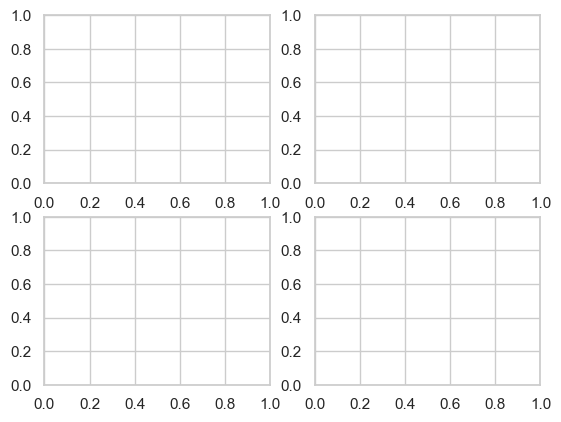

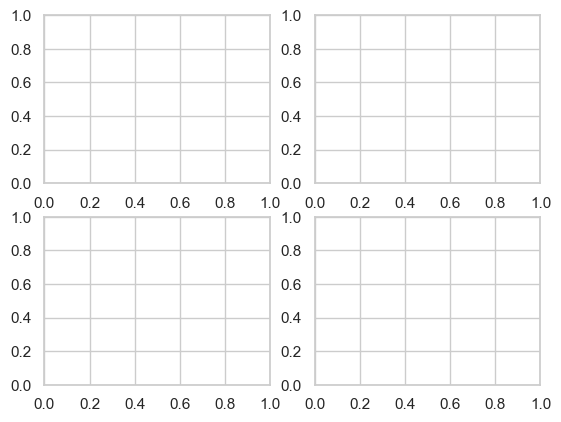

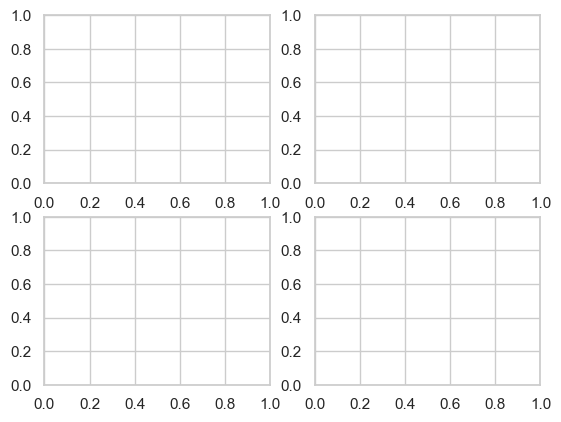

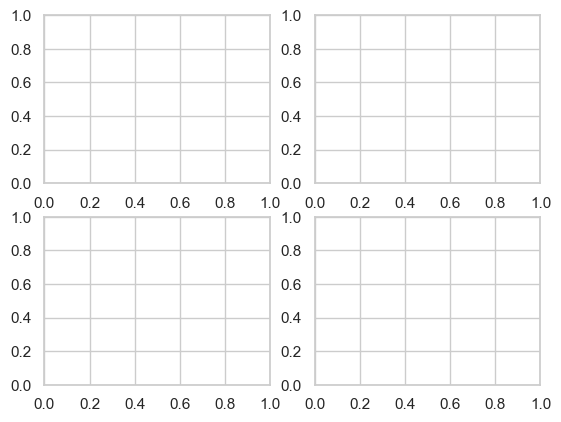

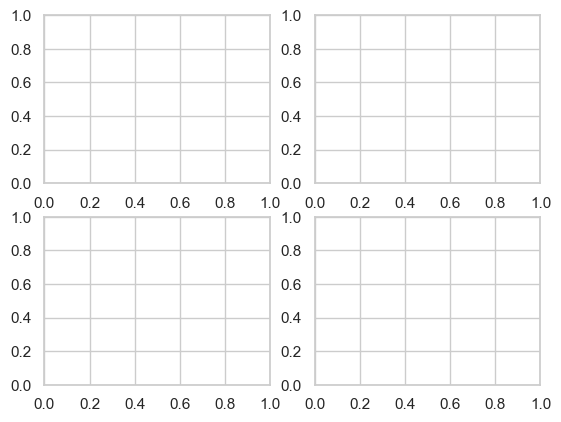

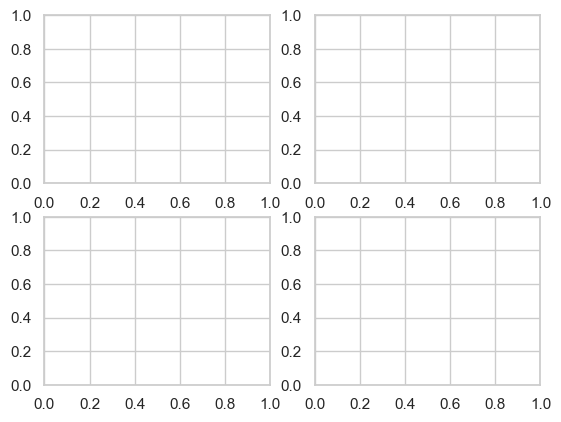

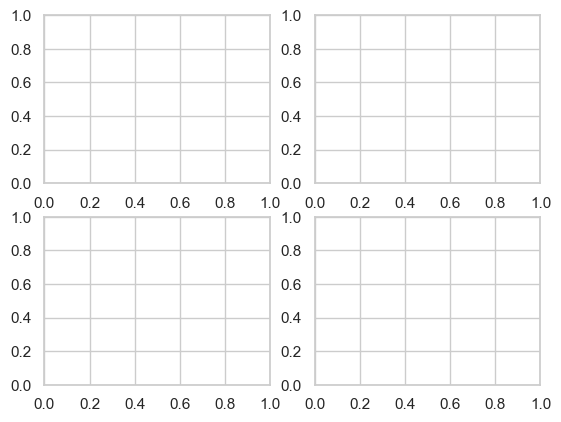

In [8]:
from FIT_python.pipeline_sex import PipelineWrapper

sex_wrapper = PipelineWrapper(**SEX_PIPELINE_PARAMS)
sex_wrapper.prepare()
sex_results = sex_wrapper.train()
sex_results.head()

## 4. Unsicherheitsanalyse für die Geschlechtsmodelle

Über `create_uncertainty_report` werden Kalibrierungs- und Vertrauensauswertungen erstellt. Zusätzlich zeigt das Notebook die automatisch erzeugten Reliability-Diagramme an.


=== eurasian_otter ===


c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[CAPTION] Reliability diagram comparing predicted and empirical sex probabilities.


c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Frede\miniforge3\envs\fit_otter_env\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one cla

,split,n_samples,accuracy,brier_score,log_loss,ece,mean_confidence,median_confidence,roc_auc,share_below_0.60,share_below_0.80,share_below_0.90,accuracy_ci_lower,accuracy_ci_upper,brier_ci_lower,brier_ci_upper,logloss_ci_lower,logloss_ci_upper,roc_auc_ci_lower,roc_auc_ci_upper
0,train,379.0,0.788918,0.141611,0.438684,0.040319,0.827934,0.879083,0.878165,0.137203,0.382586,0.556728,0.741359,0.831135,0.122540,0.163421,0.382590,0.519364,0.841411,0.911016
1,test,168.0,0.857143,0.101274,0.337240,0.072121,0.860718,0.915630,0.928204,0.071429,0.279762,0.440476,0.809524,0.904762,0.076097,0.134491,0.266986,0.433170,0.888402,0.960022
2,inference,81.0,0.481481,0.398458,1.324345,0.524202,0.822859,0.844134,NaN,0.135802,0.407407,0.604938,0.358025,0.592593,0.316757,0.467869,1.032255,1.613795,NaN,NaN


,bin,bin_lower,bin_upper,count,mean_predicted,fraction_of_positives,split
0,0,-0.000263,0.0167,38,0.006734,0.026316,train
1,1,0.016700,0.0615,38,0.036884,0.026316,train
2,2,0.061500,0.1220,38,0.090287,0.105263,train
3,3,0.122000,0.2190,38,0.167316,0.263158,train
4,4,0.219000,0.3660,38,0.275372,0.263158,train


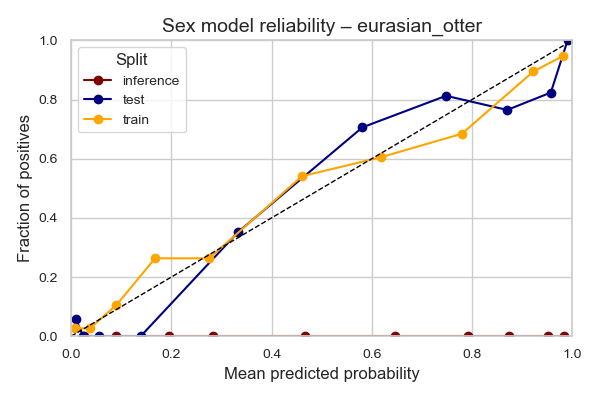

In [9]:
from IPython.display import display, Image
from FIT_python.pipeline_sex import create_uncertainty_report
from FIT_python.utils import get_species_paths

sex_uncertainty = {}
for species in TARGET_SPECIES:
    print(f"\n=== {species} ===")
    summary = create_uncertainty_report(
        species,
        bootstrap_iterations=200,
        bootstrap_confidence=0.95,
        random_state=config.GLOBAL_RANDOM_SEED,
        use_cv_train_predictions=True,
        create_plot=True,
    )
    sex_uncertainty[species] = summary
    display(summary['metrics'])
    display(summary['calibration'].head())
    paths = get_species_paths(species, section='sex_modelling')
    plot_path = paths['tables'] / 'uncertainty' / 'sex_uncertainty_reliability.png'
    if plot_path.exists():
        display(Image(filename=str(plot_path)))


## 5. Individual-ID-Pipelines trainieren

Die Individual-ID-Auswertung baut auf den vorbereiteten Splits sowie den Sex-Predictions auf. Das Training umfasst Pairwise-Modelle, UMAP-Embeddings und Siamese-Varianten.

In [10]:
from FIT_python.pipeline_individual_id.train_individual_id_pipelines import main as train_id_pipelines

for species in TARGET_SPECIES:
    print(f"\nStarte Individual-ID-Training für {species!r}...")
    train_id_pipelines(species)


ImportError: cannot import name 'geometric_pairwise_projection' from 'FIT_python.pipeline_individual_id' (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_individual_id\__init__.py)

## 6. Unsicherheitsvisualisierung für die Individual-ID-Vorhersagen

Die Trainings-Skripte legen für jede Holdout-Runde Unsicherheitsberichte ab. Wir lesen die erzeugten CSV-Dateien ein, visualisieren die Kalibrierung und stellen die Vertrauensbänder als Balkendiagramm dar.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from FIT_python.utils import get_species_paths

for species in TARGET_SPECIES:
    print(f"\n=== {species} ===")
    paths = get_species_paths(species, section='individual_id')
    summary_root = paths['tables'] / 'individual_id_pipelines'
    for split_dir in sorted(summary_root.glob('split_*_umap_uncertainty')):
        metrics_fp = split_dir / 'pairwise_uncertainty_metrics.csv'
        calib_fp = split_dir / 'pairwise_uncertainty_calibration.csv'
        conf_fp = split_dir / 'pairwise_uncertainty_confidence_bands.csv'
        print(f"  -> {split_dir.name}")
        if metrics_fp.exists():
            display(pd.read_csv(metrics_fp))
        if calib_fp.exists():
            calib_df = pd.read_csv(calib_fp)
            if not calib_df.empty:
                fig, ax = plt.subplots(figsize=(6, 5))
                ax.scatter(calib_df['mean_predicted'], calib_df['fraction_of_positives'], s=60)
                ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1)
                ax.set_title(f"Reliability – {species} ({split_dir.name})")
                ax.set_xlabel('Mean predicted probability')
                ax.set_ylabel('Fraction of positives')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                plt.show()
        if conf_fp.exists():
            conf_df = pd.read_csv(conf_fp)
            if not conf_df.empty:
                fig, ax = plt.subplots(figsize=(6, 4))
                sns.barplot(data=conf_df, x='confidence_band', y='fraction', ax=ax, color='#1f77b4')
                ax.set_title(f"Confidence bands – {species} ({split_dir.name})")
                ax.set_xlabel('Confidence band')
                ax.set_ylabel('Share of comparisons')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()


## 7. Nächste Schritte

* Die erzeugten CSV-Dateien in `results/notebook_runs/<experiment>/results/...` können für weitergehende Analysen genutzt werden.
* Über die Parameter-Dictionaries lassen sich schnell alternative Modellkonfigurationen testen.
* Für automatisierte Reports können die hier gezeigten Funktionsaufrufe in Skripte übernommen werden.